In [ ]:
from google.colab import drive
import pandas as pd

drive.mount('/content/drive')

path = '/content/drive/MyDrive/Colab Notebooks/ELEC2/(ELEC2) Mini Project/'

train_df = pd.read_csv(path + "training_cleaned_full.csv")
test_df = pd.read_csv(path + "test (1).csv")

print(f"Train Shape: {train_df.shape}")
print(f"Test Shape: {test_df.shape}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train Shape: (149049, 4)
Test Shape: (16556, 5)


# Prepping the Data

In [ ]:
import numpy as np
import re
import string

# Cleaning Function
def clean_text_func(text):
    text = str(text).lower()
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>+', '', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\n', '', text)
    text = re.sub(r'\w*\d\w*', '', text)
    return text

# Prepare Test Data (Combine Title + Content)
test_df['title'] = test_df['title'].fillna('')
test_df['content'] = test_df['content'].fillna('')

# Create combined column
test_df['combined_raw'] = test_df['title'] + " " + test_df['content']

# Apply Cleaning
print(" > Cleaning Test Data...")
test_df['clean_text'] = test_df['combined_raw'].apply(clean_text_func)

# Prepare Training Data
train_df = train_df.dropna(subset=['clean_text'])

# Set Labels (y)
y_train = train_df['classification']
y_test = test_df['classification']

print(f"Data Ready! Train: {len(y_train)} rows, Test: {len(y_test)} rows")

 > Cleaning Test Data...
Data Ready! Train: 113951 rows, Test: 16556 rows


In [ ]:
!pip install gensim

# Vectorization
# TF-IDF and Word2Vec

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec

# TF-IDF
print("1. TF-IDF (3000 Features)...")
tfidf = TfidfVectorizer(max_features=3000)
X_train_tfidf = tfidf.fit_transform(train_df['clean_text']).toarray()
X_test_tfidf = tfidf.transform(test_df['clean_text']).toarray()

# WORD2VEC
print("2. Word2Vec (100 Features)...")
# Tokenize
train_tokens = [str(t).split() for t in train_df['clean_text']]
test_tokens = [str(t).split() for t in test_df['clean_text']]

# Train W2V model on Training Data ONLY
w2v_model = Word2Vec(train_tokens, vector_size=100, window=5, min_count=1, workers=4)

def get_vector(doc):
    words = [word for word in doc if word in w2v_model.wv]
    if len(words) > 0:
        return np.mean([w2v_model.wv[word] for word in words], axis=0)
    else:
        return np.zeros(100)

X_train_w2v = np.array([get_vector(doc) for doc in train_tokens])
X_test_w2v = np.array([get_vector(doc) for doc in test_tokens])

print("Vectorization Complete.")

1. TF-IDF (3000 Features)...
2. Word2Vec (100 Features)...
Vectorization Complete.


# Model Training (Raw Data)
# TF-IDF vs Word2Vec
# Logistic Regression vs Random Forest vs LinearSVM

--- PHASE 2: TRAINING MODELS ---

[ Dataset: TF-IDF ]
 > Logistic Regression: 50.90%
 > Random Forest: 48.64%
 > SVM (Linear): 50.80%

[ Dataset: Word2Vec ]
 > Logistic Regression: 55.53%
 > Random Forest: 49.22%
 > SVM (Linear): 55.51%

--- FINAL RESULTS ---
    Dataset                Model  Accuracy
3  Word2Vec  Logistic Regression  0.555267
5  Word2Vec         SVM (Linear)  0.555146
0    TF-IDF  Logistic Regression  0.509000
2    TF-IDF         SVM (Linear)  0.508033
4  Word2Vec        Random Forest  0.492208
1    TF-IDF        Random Forest  0.486410


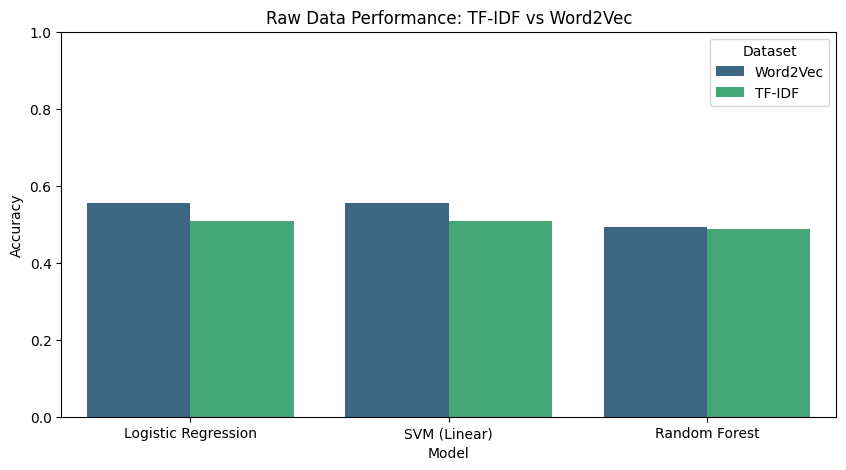

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("--- PHASE 2: TRAINING MODELS ---")

# Models
models = [
    ("Logistic Regression", LogisticRegression(max_iter=1000, n_jobs=-1)),
    ("Random Forest", RandomForestClassifier(n_estimators=100, n_jobs=-1)),
    ("SVM (Linear)", LinearSVC(dual=False))
]

results = []

# Loop 1: TF-IDF Data
print("\n[ Dataset: TF-IDF ]")
for name, model in models:
    model.fit(X_train_tfidf, y_train)
    acc = accuracy_score(y_test, model.predict(X_test_tfidf))
    results.append({"Dataset": "TF-IDF", "Model": name, "Accuracy": acc})
    print(f" > {name}: {acc:.2%}")

# Loop 2: Word2Vec Data
print("\n[ Dataset: Word2Vec ]")
for name, model in models:
    model.fit(X_train_w2v, y_train)
    acc = accuracy_score(y_test, model.predict(X_test_w2v))
    results.append({"Dataset": "Word2Vec", "Model": name, "Accuracy": acc})
    print(f" > {name}: {acc:.2%}")

# FINAL SCOREBOARD
print("\n--- FINAL RESULTS ---")
final_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False)
print(final_df)

# Visualization
plt.figure(figsize=(10,5))
sns.barplot(data=final_df, x="Model", y="Accuracy", hue="Dataset", palette="viridis")
plt.title("Raw Data Performance: TF-IDF vs Word2Vec")
plt.ylim(0, 1.0)
plt.show()